In [2]:
#!/Users/michael/envs/bsb/bin/python
# adapted from https://trvrm.github.io/fractal-dimension.html

import numpy as np
import skimage
import matplotlib.pyplot as plt
from skimage import io
from skimage.filters import threshold_otsu
from skimage.color import rgb2gray
from skimage.util import crop, invert
from scipy.stats import linregress
import math
import os
import sys

if len(sys.argv) < 3:
	print("missing parameters!")
	print("usage: fractalDim.py seg_dir color_dir v d")
	print("seg_dir is 'path/to/segmentation/images', color_dir is 'path/to/color/images, v visualizes each result")
	print("d prints the output for each image as the fractal dimension is calculated")
	print("use `fractalDim.py seg_dir color_dir v > results.txt` to save results")
	sys.exit()

# handle args
segs = sys.argv[1]
clrs = sys.argv[2]
viz = False
disp = False
if sys.argv[3] == "v":
	viz = True
if sys.argv[4] == "d":
	disp = True

slist = sorted(os.listdir(segs))
if '.DS_Store' in slist:
	slist.remove('.DS_Store')

clist = sorted(os.listdir(clrs))
if '.DS_Store' in clist:
	clist.remove('.DS_Store')

"""
	Read the image and preprocess for fractal dimension calculation
"""
def loadImage(img):
	im = skimage.io.imread(img)
	ht, wd = im.shape[0], im.shape[1]
	imb = binaryThreshold(im)
	imn = invert(imb)
	return imn, ht, wd

"""
	Apply Otsu thresholding to the image and binarize the passed image 
"""
def binaryThreshold(img):
	thresh = threshold_otsu(img)
	binary =  img > thresh
	return binary

def fracable(img):
	return 0 in set(img.flatten())

"""
	Successively crop the image and count the number of tiles containing black pixels
"""
def countBoxes(img, length, height, width):
	h, w = height, width
	boxCount = 0
	specialCount = 0
	for x in range(w//length):
		for y in range(h//length):
			#img[b:d, a:c] === crop((a, b, c, d))
			a = x*length
			b = y*length
			c = (x+1)*length
			d = (y+1)*length
			choppedImg = img[b:d, a:c]
			boxCount+=1
			if fracable(choppedImg):
				specialCount+=1
	return specialCount

"""
	Count the number of boxes at each scale possible for the dimensions of the given image. 
	Generates a pair representing the numerator and denominator of the fractal dimension equation.
	A list of these pairs is used to calculate the slope when the loop exits.
"""
def getBoxCounts(img, height, width):
	length = min(height, width)
	while length > 5:
		special = countBoxes(img, length, height, width)
		yield math.log(1.0/length), math.log(special)
		length = (length//2)

"""
	Stores all of the (scale ,box count) pairs for the final fractal dimension calculation
"""
def allCounts(img, height, width):
	return (list(getBoxCounts(img, height, width)))

"""
	Calculate the slope between the number of boxes and scales with linregress; return fractal 
	dimension value
"""
def getFractalDimension(img, height, width):
	f = allCounts(img, height, width)
	x = [g[0] for g in f]
	y = [g[1] for g in f]
	fd = linregress(x,y).slope
	return fd

fdlist = []
for i in range(len(slist)):
	print("image ", clist[i])
	cimg = clrs + "/" + clist[i]
	simg = segs + "/" + slist[i]
	colorImg = skimage.io.imread(cimg)
	segImg, h, w = loadImage(simg)
	fd = getFractalDimension(segImg, h, w)
	fdlist.append(fd)

	if disp:
		print(f"fractal dimension of {slist[i][:-4]}: {fd}")

	if viz:
		fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.2), sharex=True, sharey=True)
		ax1.imshow(colorImg)
		ax1.axis('off')
		ax1.set_title('original')
		ax2.imshow(segImg, cmap='gray')
		ax2.axis('off')
		ax2.set_title('inverted segmentation')
		plt.show()
print(fdlist)


missing parameters!
usage: fractalDim.py seg_dir color_dir v d
seg_dir is 'path/to/segmentation/images', color_dir is 'path/to/color/images, v visualizes each result
d prints the output for each image as the fractal dimension is calculated
use `fractalDim.py seg_dir color_dir v > results.txt` to save results


SystemExit: 

/home/xkw/anaconda3/envs/prior/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


/home/xkw/anaconda3/envs/prior/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xkw/anaconda3/envs/prior/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24418 (\N{CJK UNIFIED IDEOGRAPH-5F62}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xkw/anaconda3/envs/prior/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xkw/anaconda3/envs/prior/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xkw/anaconda3/envs/prior/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: User

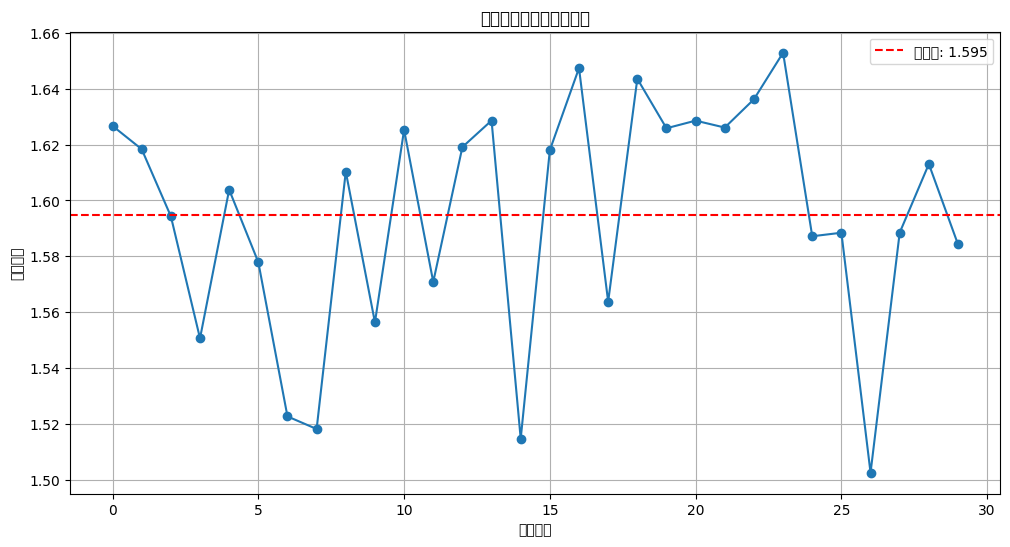

平均分形维数: 1.595
标准差: 0.041
min: 1.503
max: 1.653


In [4]:
# 绘制折线图
data = [1.626661377804779, 1.6183226584926145, 1.5943155981179333, 1.5506343201844817, 
        1.6038279205568557, 1.5778833661507057, 1.5226798967266564, 1.5181872799503147,
        1.610299332662828, 1.5563544466101833, 1.625258698093327, 1.5708200163737704,
        1.6190967018829927, 1.6285780175960967, 1.5146955006846239, 1.6180001046094719,
        1.6473564244249184, 1.5637303668471374, 1.6435365281210825, 1.6258197862796795,
        1.6285489575746124, 1.6260698369752582, 1.6361975075206658, 1.6528566431070366,
        1.5871658602475252, 1.5884304478763567, 1.502533733697144, 1.5884609932184572,
        1.613016637757723, 1.58426737641038]

plt.figure(figsize=(12, 6))
plt.plot(range(len(data)), data, marker='o')
plt.grid(True)
plt.xlabel('图像序号')
plt.ylabel('分形维数')
plt.title('不同图像的分形维数分布')

# 计算平均值和标准差
mean_val = np.mean(data)
std_val = np.std(data)
min_val = np.min(data)
max_val = np.max(data)

# 添加平均值线
plt.axhline(y=mean_val, color='r', linestyle='--', label=f'平均值: {mean_val:.3f}')

plt.legend()
plt.show()

print(f'平均分形维数: {mean_val:.3f}')
print(f'标准差: {std_val:.3f}')
print(f'min: {min_val:.3f}')
print(f'max: {max_val:.3f}')


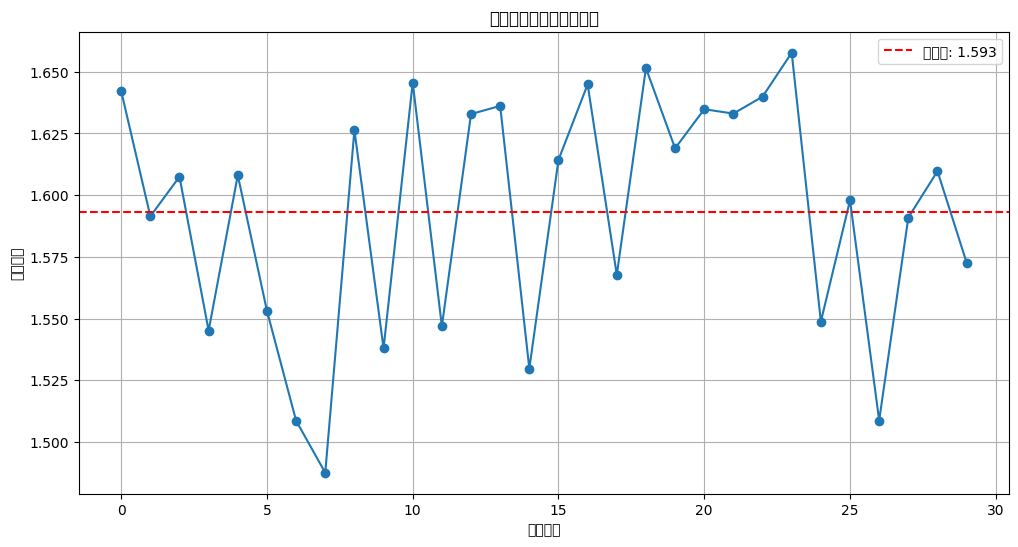

平均分形维数: 1.593
标准差: 0.048
min: 1.488
max: 1.658


In [6]:
data = [1.642192821533159, 1.5914288747988852, 1.607461368040709, 1.5451150526952795, 1.6080739718524821, 1.5531615574464996, 1.5086363413520854, 1.4875532775774556, 1.6263538686531878, 1.5379737114952265, 1.6456297931647168, 1.5468800603287685, 1.6328527585571648, 1.6361592696799434, 1.529749322007996, 1.6142962011487636, 1.644871788864279, 1.56770032030144, 1.651467882867882, 1.618976083570879, 1.6348056713008041, 1.6330539218780589, 1.639898120124091, 1.6577027137203282, 1.5487480634307544, 1.5979166239477574, 1.5087061850604768, 1.5909260572131398, 1.609712182921991, 1.5726791434826173]


plt.figure(figsize=(12, 6))
plt.plot(range(len(data)), data, marker='o')
plt.grid(True)
plt.xlabel('图像序号')
plt.ylabel('分形维数')
plt.title('不同图像的分形维数分布')

# 计算平均值和标准差
mean_val = np.mean(data)
std_val = np.std(data)
min_val = np.min(data)
max_val = np.max(data)

# 添加平均值线
plt.axhline(y=mean_val, color='r', linestyle='--', label=f'平均值: {mean_val:.3f}')

plt.legend()
plt.show()

print(f'平均分形维数: {mean_val:.3f}')
print(f'标准差: {std_val:.3f}')
print(f'min: {min_val:.3f}')
print(f'max: {max_val:.3f}')
